## 분석 개요

본 분석의 목적은 **최근 3개월 사용자 리뷰 데이터**를 바탕으로 쿠팡 앱의 **VoC(Voice of Customer)**를 조사하고, 주요 불만 및 개선 포인트를 구조적으로 정리하는 것이다.

리뷰 텍스트는 무의미한 리뷰를 일부 제거한 뒤, 사용자가 실제로 불편을 느끼는 지점을 중심으로 분류한다. 이를 통해 단순 감정 표현이 아니라 운영, 기획, 개발 관점에서 활용 가능한 액션 아이템을 도출하는 것을 목표로 한다.

### 품질 속성 분류 개요

- 전략
- UX
- 운영
- 기술


---

## 1. 데이터 전처리

In [281]:
import pandas as pd

df = pd.read_csv('data/coupang_reviews_2026_q1.csv', parse_dates=['date'])
df = df[(df['date'] >= '2026-01-01') & (df['date'] < '2026-04-01')]
print(f'{len(df):,}건 (2026-01 ~ 03)')
print(f'컬럼: {list(df.columns)}')
print(f'\n별점 분포:')
print(df['score'].value_counts().sort_index())
df.head()

1,026건 (2026-01 ~ 03)
컬럼: ['date', 'score', 'text', 'version', 'thumbsUp', 'replyText', 'userName']

별점 분포:
score
1    695
2     38
3     49
4     31
5    213
Name: count, dtype: int64


,date,score,text,version,thumbsUp,replyText,userName
0,2026-03-31,1,극혐,8.8.8,3,NaN,하두현
1,2026-03-31,1,쿠팡 리뷰가 안보여요 ㅠㅠ999+인데 확인하면 리뷰등록이 없대요 ㅠ 최근업뎃하고나서...,9.1.5,1,NaN,신수연
2,2026-03-31,3,와우 맴버십 가입에 오류가 걸려서 가입이 안돼내요!!! 확인 좀 해주세요.,NaN,0,NaN,Gunpil Jung
3,2026-03-31,4,"로켓배송, 로켓프레시, 와우회원 및 결제나 구매, 쇼핑의 간편함은 최상이라고 봅니다...",9.1.5,1,NaN,ViViD
4,2026-03-31,1,ㅋㅋㅋㅋㅋㅋ오류 투성이 비싸기도 하고요~,9.1.5,2,NaN,김은수


### 텍스트 전처리

VoC 분류 전에 노이즈를 제거하고 표기를 통일한다.

1. **초단문 제거**: 5자 이하 리뷰 (극혐, 굿, 탈팡 등) — 분류할 맥락 없음
2. **자음/모음 제거**: ㅇㄴ, ㅋㅋ, ㅠㅠ 등 자음·모음만으로 된 토큰 삭제
3. **표기 정규화**: 같은 의미의 표기 변형 통일 (업뎃→업데이트, 맴버십→멤버십, 알람→알림)
4. **반복 문자 축소**: !!!→!, ???→?
5. **이모지 제거**

In [282]:
import re

# 1. 초단문 제거 (한글/영문 기준 5자 이하)
plain = df['text'].fillna('').apply(lambda t: re.sub(r'[^가-힣a-zA-Z0-9\s]', '', t).strip())
short_mask = plain.str.len() <= 5
print(f'초단문 제거: {short_mask.sum()}건')
df = df[~short_mask].copy()

# 2. 자음/모음만으로 된 토큰 제거 (ㅇㄴ, ㅋㅋ, ㅠㅠ 등)
df['text'] = df['text'].apply(lambda t: re.sub(r'\b[ㄱ-ㅎㅏ-ㅣ]+\b', '', str(t)))

# 3. 표기 정규화 (표기 변형만 — 어미 변환은 하지 않음)
NORMALIZE = [
    (r'업뎃', '업데이트'),
    (r'맴버[십쉽]|멤버[쉽]', '멤버십'),
    (r'알[람]', '알림'),
    (r'푸[쉬]', '푸시'),
    (r'쓰[래]기', '쓰레기'),
    (r'개인 ?정보', '개인정보'),
    (r'로[켓캣] ?배송', '로켓배송'),
]
for pattern, repl in NORMALIZE:
    df['text'] = df['text'].str.replace(pattern, repl, regex=True)

# 4. 반복 문자 축소
df['text'] = df['text'].str.replace(r'(ㅋ){2,}', 'ㅋㅋ', regex=True)
df['text'] = df['text'].str.replace(r'(ㅎ){2,}', 'ㅎㅎ', regex=True)
df['text'] = df['text'].str.replace(r'(ㅠ){2,}', 'ㅠㅠ', regex=True)
df['text'] = df['text'].str.replace(r'(ㅜ){2,}', 'ㅜㅜ', regex=True)
df['text'] = df['text'].str.replace(r'(!){2,}', '!', regex=True)
df['text'] = df['text'].str.replace(r'(\?){2,}', '?', regex=True)

# 5. 이모지 제거
df['text'] = df['text'].str.replace(r'[^\w\s가-힣.,!?~\-\(\)\[\]:;/\'\"@#%&*+<>]', '', regex=True)

# 연속 공백 정리
df['text'] = df['text'].str.replace(r'\s+', ' ', regex=True).str.strip()

# 결과
print(f'전처리 후: {len(df)}건')
df[['score','text']].sample(5, random_state=42)

초단문 제거: 132건
전처리 후: 894건


,score,text
812,1,개인정보수집을 그렇게 많이하는데 보호를 못함
496,1,번호 바꿨는데에도 옛날 번호로 인증하라하믄 우짜노 쿠팡 일 똑바로 안하냐 장난하는것...
599,1,학생이어서 와우 멤버십을 하기 어려운데 요즘은 상품들 대부분이 와우 할인이 들어가서...
826,5,저는 다른 쇼핑몰 한번씩 검색하는데 달달이 등록비 없어도 제가 찾는건 없거나 비쌈....
43,1,납치가심하다


### 형태소 분석 (토큰화)

전처리된 텍스트를 kiwipiepy 형태소 분석기로 토큰화한다. 조사, 어미 등을 분리하여 **동일 의미의 표현이 하나의 토큰으로 통일**되도록 한다.

- "리뷰가", "리뷰를", "리뷰도" → `리뷰`
- "안보여요", "안보임", "안보인다" → `보이`
- 명사(NNG, NNP), 동사(VV), 형용사(VA), 부사(MAG)만 추출하여 분류에 불필요한 노이즈를 제거한다.

In [283]:
from kiwipiepy import Kiwi

kiwi = Kiwi()
KEEP_TAGS = {'NNG', 'NNP', 'VV', 'VA', 'MAG'}

def tokenize(text):
    tokens = kiwi.tokenize(str(text))
    return [t.form for t in tokens if t.tag in KEEP_TAGS]

df['tokens'] = df['text'].apply(tokenize)

# 토큰화 결과 확인
sample = df[['score', 'text', 'tokens']].sample(5, random_state=42)
for _, row in sample.iterrows():
    print(f'[{row["score"]}점] {row["text"][:50]}')
    print(f'  → {row["tokens"][:15]}')
    print()

[1점] 개인정보수집을 그렇게 많이하는데 보호를 못함
  → ['개인', '정보', '수집', '많이', '하', '보호', '못', '하']

[1점] 번호 바꿨는데에도 옛날 번호로 인증하라하믄 우짜노 쿠팡 일 똑바로 안하냐 장난하는것도 아니
  → ['번호', '바꾸', '옛날', '번호', '인증하라하믄', '우짜', '쿠팡', '일', '똑바로', '안', '하', '장난']

[1점] 학생이어서 와우 멤버십을 하기 어려운데 요즘은 상품들 대부분이 와우 할인이 들어가서 구매 
  → ['학생', '와우', '멤버십', '하', '요즘', '상품', '대부분', '와우', '할인', '들어가', '구매', '하', '할인', '좋', '무조건']

[5점] 저는 다른 쇼핑몰 한번씩 검색하는데 달달이 등록비 없어도 제가 찾는건 없거나 비쌈.(제가 
  → ['쇼핑몰', '검색', '달', '달', '등록비', '없', '찾', '없', '비싸', '쿠팡', '외국인', '바지', '사장단', '동문서답', '또']

[1점] 납치가심하다
  → ['납치', '심하']



---

### VoC 상위 분류 체계

리뷰 텍스트는 최종적으로 **전략 / UX / 운영 / 기술**의 4개 상위 범주로 요약한다. 세부 라벨은 내부 분류에 활용하되, 리포트에서는 보다 일반적인 수준으로 묶어서 해석한다.

| 상위 범주 | 포함 관점 | 예시 이슈 |
|---|---|---|
| 전략 | 경제성, 적합성 | 가격 부담, 혜택 체감 부족, 정책/멤버십 조건, 타겟 적합성 |
| UX | 편의성, 직관성, 심미성, 감성 | 사용 불편, 복잡한 흐름, UI 완성도, 정서적 거부감 |
| 운영 | 고객지원성 | 문의 채널 접근성, 응답 속도, 처리 정확성, 안내 투명성 |
| 기술 | 안정성 | 오류, 튕김, 속도 저하, 보안/개인정보 우려 |

이후 집계와 해석은 이 4개 범주를 기준으로 진행한다.


---

## 2. VoC 분류

전처리된 894건의 리뷰를 별점과 텍스트를 함께 참고하여 4개 상위 범주로 분류했다. 하나의 리뷰가 여러 범주에 해당할 수 있으며(복수 분류), 구체적인 이슈가 없는 단순 감정 표현은 미분류(X)로 처리했다.

In [284]:
import json

with open('data/voc_classification_claude.json', 'r', encoding='utf-8') as f:
    voc_labels = json.load(f)

# 분류 결과 매핑
df['voc_categories'] = df.index.map(lambda i: voc_labels.get(str(i), ['X']))
df['sentiment'] = df['score'].apply(lambda s: '긍정' if s >= 4 else ('부정' if s <= 2 else '중립'))

# 분류 현황
total = len(df)
classified = df['voc_categories'].apply(lambda c: c != ['X']).sum()
print(f'전체: {total}건')
print(f'분류: {classified}건 ({classified/total*100:.0f}%)')
print(f'미분류(X): {total - classified}건 ({(total-classified)/total*100:.0f}%)')

# 범주별 건수 (복수 분류 포함)
from collections import Counter
cat_counts = Counter()
for cats in df['voc_categories']:
    for c in cats:
        if c != 'X':
            cat_counts[c] += 1

print(f'\n범주별 건수 (복수 분류 포함):')
for cat, cnt in cat_counts.most_common():
    print(f'  {cat}: {cnt}건 ({cnt/classified*100:.0f}%)')

# 샘플 확인
print(f'\n--- 분류 샘플 ---')
sample = df[df['voc_categories'].apply(lambda c: c != ['X'])].sample(5, random_state=42)
for _, row in sample.iterrows():
    print(f'[{row["score"]}점] {row["voc_categories"]} {row["text"][:60]}')

전체: 894건
분류: 684건 (77%)
미분류(X): 210건 (23%)

범주별 건수 (복수 분류 포함):
  UX: 235건 (34%)
  전략: 232건 (34%)
  기술: 210건 (31%)
  운영: 144건 (21%)

--- 분류 샘플 ---
[1점] ['전략'] 이번에 받은 쿠폰도 5000원 이하로 겨우 찾아서 사려고 했더니 20000원을 넘어야 로켓배송을 쓰거나 와우
[3점] ['기술'] 지금 계속 인터넷 연결이 안되었다면서 어플 작동이 안됩니다
[1점] ['UX'] 최근 본 상품 왜 없어졌나요? 아무리 찾아도 안보리고 고객센터에서도 없어졌다하던데 다시 부활시켜주세요
[1점] ['운영'] 여기 리뷰도 돌려 막기 조작하는거 다 보인다 ~ 악행의 끝판왕 더러운 기업. 하는 행실때문에 구매자들이 감정
[1점] ['전략'] 와우 가입안하면 소액결제가 안됌.


In [285]:
# 범주별 감정 분포
rows = []
for category in ['전략', 'UX', '운영', '기술']:
    mask = df['voc_categories'].apply(lambda cats: category in cats)
    sub = df[mask]
    neg = (sub['sentiment'] == '부정').sum()
    pos = (sub['sentiment'] == '긍정').sum()
    neu = (sub['sentiment'] == '중립').sum()
    rows.append({
        '범주': category,
        '건수': len(sub),
        '부정': int(neg),
        '긍정': int(pos),
        '중립': int(neu),
        '부정비율': f'{neg/len(sub)*100:.0f}%' if len(sub) > 0 else '-'
    })

result = pd.DataFrame(rows)
print(result.to_string(index=False))

# 감정별 전체 분포
print(f'\n감정 분포 (분류된 리뷰 기준):')
classified_df = df[df['voc_categories'].apply(lambda c: c != ['X'])]
print(classified_df['sentiment'].value_counts().to_string())

범주  건수  부정  긍정  중립 부정비율
전략 232 203  17  12  88%
UX 235 193  19  23  82%
운영 144 111  25   8  77%
기술 210 177  20  13  84%

감정 분포 (분류된 리뷰 기준):
sentiment
부정    557
긍정     80
중립     47


---

## 3. 만족도 스코어링

단순 별점이 아닌, 리뷰 텍스트의 **감성 강도**와 **심각도**를 함께 반영하여 0~100점 만족도를 산출한다.

### 기본 공식

```
score_reality = 80 + (sentiment_score × severity_multiplier)
```

최종 점수는 0~100 범위로 clip한다.

### 감성 점수 (sentiment_score)

| 등급 | 점수 | 판정 기준 |
|---|---|---|
| 매우 긍정 | +20 | 별점 5점 + 긍정 표현 (좋아요, 최고, 만족, 편리 등) |
| 긍정 | +10 | 별점 4~5점 |
| 중립 | 0 | 별점 3점 |
| 부정 | -10 | 별점 1~2점 |
| 매우 부정 | -20 | 별점 1점 + 강한 부정 표현 |

### 심각도 배수 (severity_multiplier)

| 등급 | 배수 | 판정 기준 |
|---|---|---|
| 일반 | ×1.0 | 기본값 |
| 반복/누적 | ×1.5 | 또, 계속, 자꾸, 몇 번째, 매번, 맨날 |
| 이탈/강한 부정 | ×2.0 | 탈퇴, 삭제, 해지, 다신 안 쓴다, 사기, 최악, 극혐 |

반복 표현 + 강한 부정 표현이 함께 있으면 ×2.5를 적용한다.

In [286]:
import re

# --- 감성 판정 키워드 ---
VERY_POSITIVE_KW = re.compile(r'좋아요|최고|만족|편리|편해|사랑|감사|응원|화이팅|파이팅|잘\s*쓰|잘\s*사용|빠르고.*좋|좋고.*빠')
VERY_NEGATIVE_KW = re.compile(r'탈[퇴팡회]|삭제|해지|안\s*쓴다|안\s*씀|못\s*믿|사기|거짓말|최악|극혐|역[겹겨]|꺼져|망[해하]|지움|사라져|불매|신고')
REPEAT_KW = re.compile(r'또|계속|자꾸|몇\s*번째|매번|맨날|항상|맨날|반복|여러\s*번|몇\s*번')

def calc_sentiment(score, text):
    """별점 + 텍스트로 감성 등급과 점수 판정 (대칭 기준)"""
    t = str(text)

    if score >= 5 and VERY_POSITIVE_KW.search(t):
        return '매우 긍정', 20
    if score >= 4:
        return '긍정', 10
    if score == 3:
        return '중립', 0
    # 별점 1~2
    if score == 1 and VERY_NEGATIVE_KW.search(t):
        return '매우 부정', -20
    return '부정', -10

def calc_severity(text):
    """텍스트에서 심각도 등급과 배수 판정"""
    t = str(text)
    has_repeat = bool(REPEAT_KW.search(t))
    has_extreme = bool(VERY_NEGATIVE_KW.search(t))

    if has_repeat and has_extreme:
        return '반복+이탈', 2.5
    if has_extreme:
        return '이탈/강한 부정', 2.0
    if has_repeat:
        return '반복/누적', 1.5
    return '일반', 1.0

# --- 점수 계산 ---
df['sentiment_level'], df['sentiment_score'] = zip(*df.apply(
    lambda r: calc_sentiment(r['score'], r['text']), axis=1))

df['severity_level'], df['severity_multiplier'] = zip(*df['text'].apply(calc_severity))

df['score_reality'] = (80 + df['sentiment_score'] * df['severity_multiplier']).clip(0, 100)

# 결과 분포
print('=== 감성 등급 분포 ===')
print(df['sentiment_level'].value_counts().to_string())
print(f'\n=== 심각도 등급 분포 ===')
print(df['severity_level'].value_counts().to_string())
print(f'\n=== 만족도 점수 통계 ===')
print(f'평균: {df["score_reality"].mean():.1f}점')
print(f'중앙값: {df["score_reality"].median():.1f}점')
print(df['score_reality'].describe().to_string())

=== 감성 등급 분포 ===
sentiment_level
부정       508
매우 부정    140
긍정       117
매우 긍정     80
중립        49

=== 심각도 등급 분포 ===
severity_level
일반          652
이탈/강한 부정    140
반복/누적        76
반복+이탈        26

=== 만족도 점수 통계 ===
평균: 70.7점
중앙값: 70.0점
count    894.000000
mean      70.665548
std       17.422971
min       30.000000
25%       70.000000
50%       70.000000
75%       80.000000
max      100.000000


In [287]:
# 샘플 검증: 각 감성 등급별 대표 리뷰와 점수 산출 근거
cols = ['score', 'text', 'sentiment_level', 'sentiment_score', 'severity_level', 'severity_multiplier', 'score_reality']

print('=== 점수 산출 샘플 ===\n')
for level in ['매우 긍정', '긍정', '중립', '부정', '매우 부정']:
    sub = df[df['sentiment_level'] == level]
    if len(sub) == 0:
        continue
    row = sub.sample(1, random_state=42).iloc[0]
    print(f'[{row["score"]}점] {row["text"][:70]}')
    print(f'  감성: {row["sentiment_level"]}({row["sentiment_score"]:+d}) × 심각도: {row["severity_level"]}(×{row["severity_multiplier"]}) → {row["score_reality"]:.0f}점')
    print()

=== 점수 산출 샘플 ===

[5점] 쿠팡 화이팅!
  감성: 매우 긍정(+20) × 심각도: 일반(×1.0) → 100점

[5점] 미우나고우나 대체불가 쿠팡배송
  감성: 긍정(+10) × 심각도: 일반(×1.0) → 90점

[3점] 로켓배송이왜 4일후에 올까요? 차라리 3일이내 도착보장인 네이버를 사용하는게더 좋지않을까요? 문의는왜 시키는것마다 업무를못받을
  감성: 중립(+0) × 심각도: 일반(×1.0) → 80점

[1점] 음 최근 본 상품 시스템을 왜 없앤거지?
  감성: 부정(-10) × 심각도: 일반(×1.0) → 70점

[1점] 탈팡했다! 내가 개돼지로 보이냐?
  감성: 매우 부정(-20) × 심각도: 이탈/강한 부정(×2.0) → 40점



In [288]:
# 상위 범주별 평균 만족도 + 상태 판정
# 미분류(X)는 구체적 이슈 없는 단순 감정 표현이므로 집계에서 제외
def status_label(score):
    if score >= 75: return '양호'
    if score >= 60: return '보통'
    if score >= 45: return '주의'
    return '위험'

df_classified = df[df['voc_categories'].apply(lambda c: c != ['X'])].copy()

rows = []
for cat in ['전략', 'UX', '운영', '기술']:
    mask = df_classified['voc_categories'].apply(lambda c: cat in c)
    sub = df_classified[mask]
    avg = sub['score_reality'].mean()
    rows.append({
        '범주': cat,
        '건수': len(sub),
        '평균점수': round(avg, 1),
        '상태': status_label(avg)
    })

rows.append({
    '범주': '전체 (X 제외)',
    '건수': len(df_classified),
    '평균점수': round(df_classified['score_reality'].mean(), 1),
    '상태': status_label(df_classified['score_reality'].mean())
})

score_df = pd.DataFrame(rows)
print('=== 범주별 만족도 점수 ===')
print(score_df.to_string(index=False))

# 점수 구간별 리뷰 수
print(f'\n=== 점수 구간별 분포 (X 제외) ===')
bins = [0, 44, 59, 74, 100]
labels = ['위험(0~44)', '주의(45~59)', '보통(60~74)', '양호(75~100)']
df_classified['score_band'] = pd.cut(df_classified['score_reality'], bins=bins, labels=labels, include_lowest=True)
print(df_classified['score_band'].value_counts().sort_index().to_string())

=== 범주별 만족도 점수 ===
       범주  건수  평균점수 상태
       전략 232  65.1 보통
       UX 235  65.7 보통
       운영 144  69.3 보통
       기술 210  66.0 보통
전체 (X 제외) 684  67.6 보통

=== 점수 구간별 분포 (X 제외) ===
score_band
위험(0~44)      115
주의(45~59)       5
보통(60~74)     437
양호(75~100)    127


In [289]:
# 월별 만족도 추이 (X 제외)
df_classified['month'] = df_classified['date'].dt.to_period('M')

print('=== 월별 전체 만족도 (X 제외) ===')
monthly = df_classified.groupby('month').agg(
    건수=('score_reality', 'count'),
    평균점수=('score_reality', 'mean')
).round(1)
monthly['상태'] = monthly['평균점수'].apply(status_label)
print(monthly.to_string())

# 월별 × 범주별
print(f'\n=== 월별 × 범주별 평균 점수 ===')
rows = []
for month in sorted(df_classified['month'].unique()):
    m_df = df_classified[df_classified['month'] == month]
    row = {'월': str(month)}
    for cat in ['전략', 'UX', '운영', '기술']:
        mask = m_df['voc_categories'].apply(lambda c: cat in c)
        sub = m_df[mask]
        row[cat] = round(sub['score_reality'].mean(), 1) if len(sub) > 0 else '-'
    rows.append(row)
print(pd.DataFrame(rows).to_string(index=False))

=== 월별 전체 만족도 (X 제외) ===
          건수  평균점수  상태
month                 
2026-01  301  65.8  보통
2026-02  207  69.4  보통
2026-03  176  68.4  보통

=== 월별 × 범주별 평균 점수 ===
      월   전략   UX   운영   기술
2026-01 62.0 64.4 68.3 64.2
2026-02 68.5 66.4 71.6 68.4
2026-03 67.8 66.9 67.6 66.9


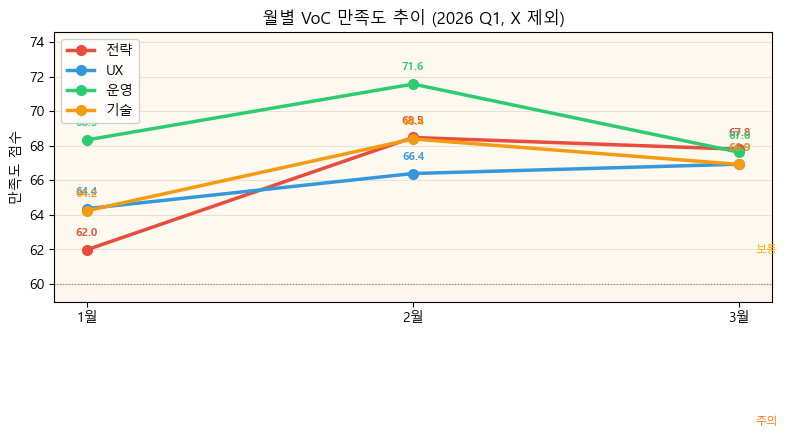

In [290]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정 (Windows)
for name in ['Malgun Gothic', 'NanumGothic', 'AppleGothic']:
    if any(name in f.name for f in fm.fontManager.ttflist):
        plt.rcParams['font.family'] = name
        break
plt.rcParams['axes.unicode_minus'] = False

months_label = ['1월', '2월', '3월']
cats = ['전략', 'UX', '운영', '기술']
colors = {'전략': '#E74C3C', 'UX': '#3498DB', '운영': '#2ECC71', '기술': '#F39C12'}

# 월별 × 범주별 데이터 (X 제외)
data = {}
for cat in cats:
    data[cat] = []
    for month in sorted(df_classified['month'].unique()):
        m_df = df_classified[df_classified['month'] == month]
        mask = m_df['voc_categories'].apply(lambda c: cat in c)
        data[cat].append(m_df[mask]['score_reality'].mean())

# y축 타이트하게
all_vals = [v for vals in data.values() for v in vals]
y_min = min(all_vals) - 3
y_max = max(all_vals) + 3

fig, ax = plt.subplots(figsize=(8, 5))

ax.axhspan(max(y_min, 0), min(45, y_max), alpha=0.08, color='red')
ax.axhspan(max(y_min, 45), min(60, y_max), alpha=0.06, color='#FF6600')
ax.axhspan(max(y_min, 60), min(75, y_max), alpha=0.06, color='orange')

for cat in cats:
    ax.plot(months_label, data[cat], marker='o', linewidth=2.5, label=cat, color=colors[cat], markersize=7)
    for i, v in enumerate(data[cat]):
        ax.annotate(f'{v:.1f}', (months_label[i], v), textcoords='offset points',
                    xytext=(0, 10), ha='center', fontsize=8, color=colors[cat], fontweight='bold')

for y in [45, 60]:
    if y_min < y < y_max:
        ax.axhline(y=y, color='gray', linewidth=0.8, linestyle=':')

if y_min < 45:
    ax.text(2.05, max(y_min + 1, 42), '위험', fontsize=8, color='red', va='center')
ax.text(2.05, 52, '주의', fontsize=8, color='#FF6600', va='center')
if y_max > 60:
    ax.text(2.05, min(y_max - 1, 62), '보통', fontsize=8, color='orange', va='center')

ax.set_ylim(y_min, y_max)
ax.set_ylabel('만족도 점수')
ax.set_title('월별 VoC 만족도 추이 (2026 Q1, X 제외)')
ax.legend(loc='upper left', framealpha=0.9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---

## 4. 개인정보 유출 영향 분리

2026년 1분기는 개인정보 유출 사건 직후 시기다. 월별 만족도 변화가 서비스 자체의 변화인지, 유출 이슈의 잔여 효과인지를 구분하기 위해 개인정보 관련 리뷰를 식별하고 제외한 뒤 다시 비교한다.

In [291]:
from scipy import stats

# 개인정보 관련 키워드 필터
PRIVACY_KW = re.compile(r'개인정보|유출|해킹|털[리렸]|보안|정보.*유출|계정.*털|정보.*털')
df_classified['has_privacy'] = df_classified['text'].apply(lambda t: bool(PRIVACY_KW.search(str(t))))

# 개인정보 키워드 월별 추이
print('=== 개인정보 키워드 월별 추이 ===')
for m in sorted(df_classified['month'].unique()):
    sub = df_classified[df_classified['month'] == m]
    priv = sub['has_privacy'].sum()
    print(f'  {m}: {priv}/{len(sub)}건 ({priv/len(sub)*100:.0f}%)')

# 개인정보 제외 후 월별 만족도
df_no_priv = df_classified[~df_classified['has_privacy']]
print(f'
=== 개인정보 제외 후 월별 만족도 ===')
for m in sorted(df_no_priv['month'].unique()):
    sub = df_no_priv[df_no_priv['month'] == m]
    print(f'  {m}: {sub["score_reality"].mean():.1f}점, {len(sub)}건')

# 검정: 개인정보 제외 후에도 1→2월 차이가 유의미한가?
jan_np = df_no_priv[df_no_priv['month'] == '2026-01']['score_reality']
feb_np = df_no_priv[df_no_priv['month'] == '2026-02']['score_reality']
u, p = stats.mannwhitneyu(jan_np, feb_np, alternative='two-sided')
print(f'
=== 개인정보 제외 후 1월 vs 2월 검정 ===')
print(f'  p={p:.4f} → {"유의미" if p < 0.05 else "유의미하지 않음"}')
if p >= 0.05:
    print(f'  → 개인정보 리뷰를 빼면 1→2월 차이가 사라진다.')
    print(f'     즉, 1월의 낮은 만족도는 유출 사건에 의한 일시적 충격이었다.')


SyntaxError: unterminated f-string literal (detected at line 16) (4287274998.py, line 16)

---

## 5. 범주별 핵심 불만 (개인정보 제외)

개인정보 유출 리뷰를 제외한 517건에서 각 범주의 실질적 불만 키워드를 확인한다.


In [ ]:
from collections import Counter

KEEP_POS = {"NNG", "NNP", "VV", "VA"}
STOP = {"하","되","있","없","쿠팡","것","거","수","좀","더","안","못","왜","뭐","이","그","저","진짜","아니","제발","정말","너무"}

def top_kw(texts, n=10):
    cnt = Counter()
    for t in texts:
        for tok in kiwi.tokenize(str(t)):
            if tok.tag in KEEP_POS and tok.form not in STOP and len(tok.form) > 1:
                cnt[tok.form] += 1
    return cnt.most_common(n)

for cat in ["전략", "UX", "운영", "기술"]:
    mask = df_no_priv["voc_categories"].apply(lambda c: cat in c)
    sub = df_no_priv[mask]
    neg = sub[sub["score_reality"] < 75]
    print(f"=== {cat} ({len(sub)}건, 불만 {len(neg)}건) ===")
    print(f"  키워드: {", ".join(f"{w}({c})" for w, c in top_kw(neg["text"]))}")
    samples = neg.sort_values("score_reality").head(3)
    for _, r in samples.iterrows():
        print(f"  [{r["score"]}점→{r["score_reality"]:.0f}점] {r["text"][:70]}")
    print()


---

## 데이터 한계

1. **플랫폼 편향**: Google Play Store 리뷰만 수집하여 안드로이드 유저만 대상이다. iOS 사용자의 VoC는 반영되지 않으며, OS별 UX 이슈나 사용자 특성이 다를 수 있다.
2. **표본 편향**: 리뷰를 작성하는 사용자는 극단적 만족/불만인 경우가 많아 중간층 의견이 과소 대표된다 (1점 68%, 5점 21%).
3. **텍스트 품질**: 짧은 감정 표현, 오탈자, 인코딩 이슈가 포함되어 있어 전처리 후에도 분류 정확도에 한계가 있다. 초단문(5자 이하) 132건은 전처리 단계에서 제거했다.
4. **시점 특수성**: 2026년 1~3월은 개인정보 유출 사건 직후 시기로, 보안성(R2) 관련 리뷰가 평소 대비 과대 반영되었을 가능성이 높다.